In [1]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature
import requests
import pandas as pd
import io
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

In [2]:
# Sets the run time and range for the Herbie run
run = pd.Timestamp("2024-11-18", tz="utc").replace(tzinfo=None).floor('24h')
fxxRange = range(0, 241, 6)

In [3]:
# Herbie run and inventory
FH = FastHerbie([run], model="gfs", product="pgrb2.0p50", fxx=fxxRange, save_dir='/home/bds5658/meteo473/sp26_groupwork/473_sp26_group9/data', overwrite=True)
FH.inventory()

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this,FILE
0,1,0,294590.0,0-294590,2024-11-18,2024-11-18,PRMSL,mean sea level,anl,:PRMSL:mean sea level:anl,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
1,2,294591,325487.0,294591-325487,2024-11-18,2024-11-18,CLMR,1 hybrid level,anl,:CLMR:1 hybrid level:anl,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
2,3,325488,429328.0,325488-429328,2024-11-18,2024-11-18,ICMR,1 hybrid level,anl,:ICMR:1 hybrid level:anl,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
3,4,429329,508062.0,429329-508062,2024-11-18,2024-11-18,RWMR,1 hybrid level,anl,:RWMR:1 hybrid level:anl,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
4,5,508063,549229.0,508063-549229,2024-11-18,2024-11-18,SNMR,1 hybrid level,anl,:SNMR:1 hybrid level:anl,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
...,...,...,...,...,...,...,...,...,...,...,...
30411,739,161540785,161703342.0,161540785-161703342,2024-11-18,2024-11-28,VGRD,PV=-2e-06 (Km^2/kg/s) surface,240 hour fcst,:VGRD:PV=-2e-06 (Km^2/kg/s) surface:240 hour fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
30412,740,161703343,161866641.0,161703343-161866641,2024-11-18,2024-11-28,TMP,PV=-2e-06 (Km^2/kg/s) surface,240 hour fcst,:TMP:PV=-2e-06 (Km^2/kg/s) surface:240 hour fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
30413,741,161866642,162152692.0,161866642-162152692,2024-11-18,2024-11-28,HGT,PV=-2e-06 (Km^2/kg/s) surface,240 hour fcst,:HGT:PV=-2e-06 (Km^2/kg/s) surface:240 hour fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
30414,742,162152693,162431126.0,162152693-162431126,2024-11-18,2024-11-28,PRES,PV=-2e-06 (Km^2/kg/s) surface,240 hour fcst,:PRES:PV=-2e-06 (Km^2/kg/s) surface:240 hour fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....


In [4]:
# Defining a search string for the desired variables and downloading the associated GRIB files
variableSearch = ":(TMP:2 m.*|UGRD:10 m.*|VGRD:10 m.*|APCP:surface|CSNOW|CRAIN|PRATE|RH:2 m.*):"
fp = FH.download(variableSearch)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [5]:
# Extracting the data from each of the GRIB files and merging them into one variable using xarray

# The data was broken into three subsets. ds1 is set to a height above ground of 2, specifically for 2m temperature.
ds1 = xr.open_mfdataset(fp, engine = 'cfgrib', backend_kwargs={'filter_by_keys': {'typeOfLevel': 'heightAboveGround', 'level':2}}, combine='nested', concat_dim='valid_time')

# ds2 is set to a level of 10, which was used for gathering 10m wind in the u and v directions.
ds2 = xr.open_mfdataset(fp, engine = 'cfgrib', backend_kwargs={'filter_by_keys': {'typeOfLevel': 'heightAboveGround', 'level':10}}, combine='nested', concat_dim='valid_time')

#ds3 is set to surface level, which is used to monitor the current precipitation at the surface (rain or snow).
ds3 = xr.open_mfdataset(fp, engine = 'cfgrib', backend_kwargs={'filter_by_keys': {'typeOfLevel': 'surface', 'stepType':'instant'}}, combine='nested', concat_dim='valid_time')

ds = xr.merge([ds1, ds2, ds3], compat = 'override')

# Used AI to fix the longitude range to match with cartopy
ds = ds.assign_coords(longitude = (((ds.longitude + 180) % 360) - 180))

Ignoring index file '/home/bds5658/meteo473/sp26_groupwork/473_sp26_group9/data/gfs/20241118/subset_65ef6e41__gfs.t00z.pgrb2.0p50.f000.da267.idx' older than GRIB file
Ignoring index file '/home/bds5658/meteo473/sp26_groupwork/473_sp26_group9/data/gfs/20241118/subset_6505b080__gfs.t00z.pgrb2.0p50.f084.da267.idx' older than GRIB file
Ignoring index file '/home/bds5658/meteo473/sp26_groupwork/473_sp26_group9/data/gfs/20241118/subset_6560b080__gfs.t00z.pgrb2.0p50.f030.da267.idx' older than GRIB file
Ignoring index file '/home/bds5658/meteo473/sp26_groupwork/473_sp26_group9/data/gfs/20241118/subset_6532b080__gfs.t00z.pgrb2.0p50.f066.da267.idx' older than GRIB file
Ignoring index file '/home/bds5658/meteo473/sp26_groupwork/473_sp26_group9/data/gfs/20241118/subset_6589b080__gfs.t00z.pgrb2.0p50.f018.da267.idx' older than GRIB file
Ignoring index file '/home/bds5658/meteo473/sp26_groupwork/473_sp26_group9/data/gfs/20241118/subset_6507b080__gfs.t00z.pgrb2.0p50.f096.da267.idx' older than GRIB fil

In [6]:
# Sorting the data chronologically and removing data outside of the continental US. 
ds = ds.sortby('valid_time')
ds = ds.sel(latitude=slice(60,24), longitude=slice(-130, -65))

In [7]:
# Setting the file name and creating the NetCDF file from the data assigned to ds
fname = 'PITCLE'
path = f"/home/bds5658/meteo473/sp26_groupwork/473_sp26_group9/data/{fname}.3nc"
ds.to_netcdf(path)

sh: 1: getfattr: not found


sh: 1: getfattr: not found


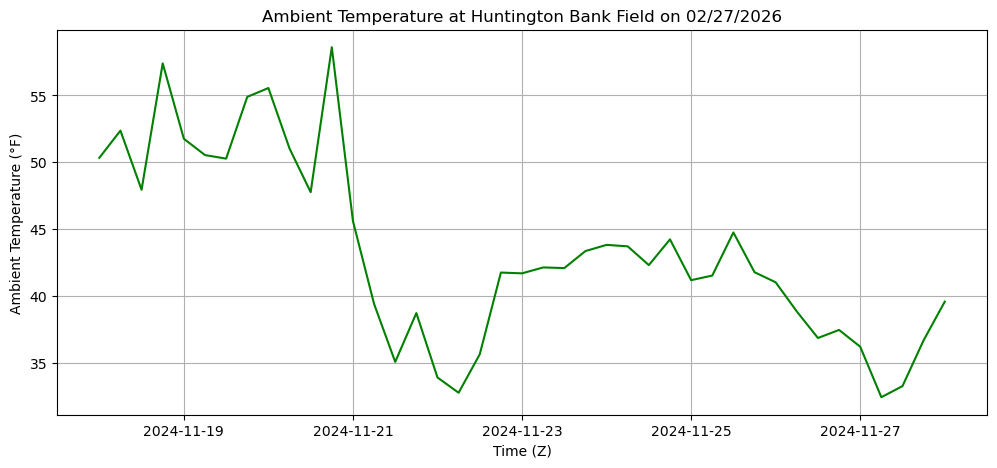

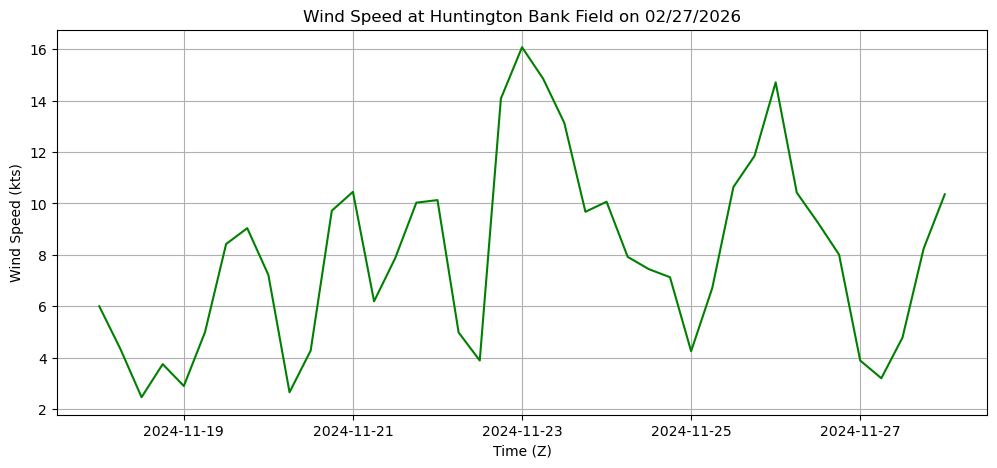

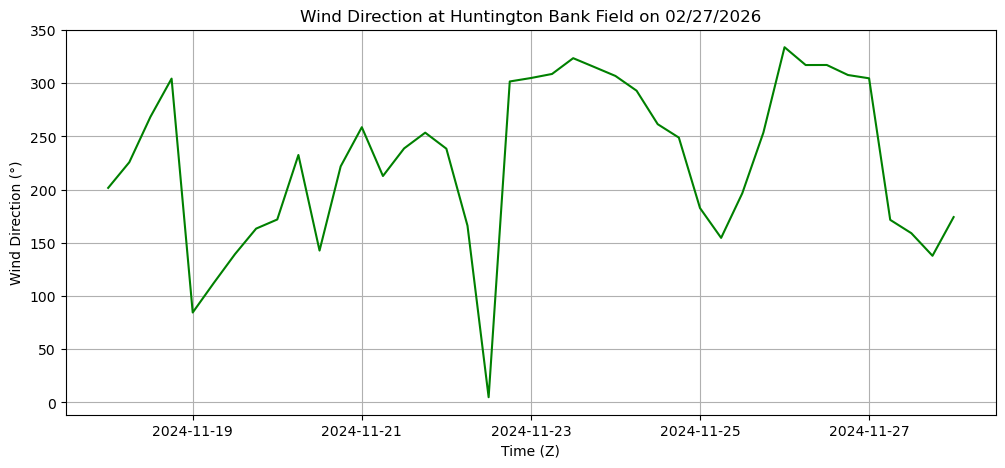

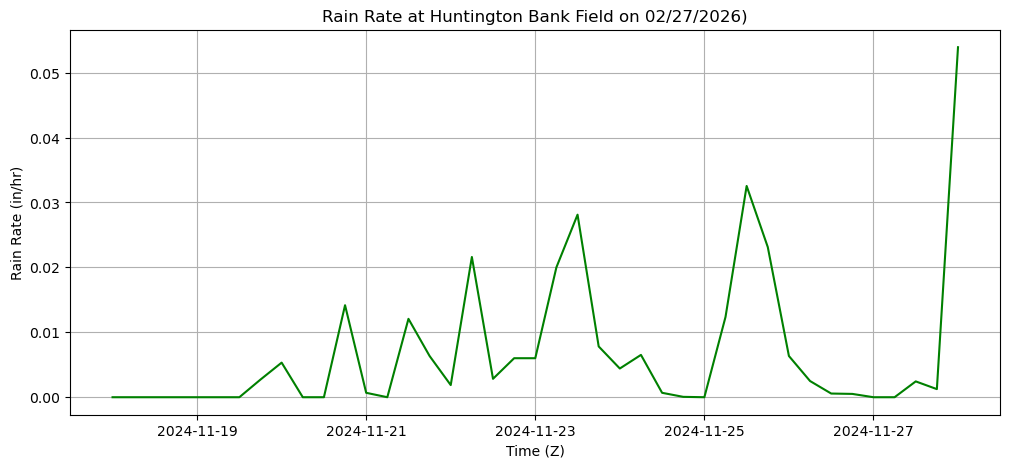

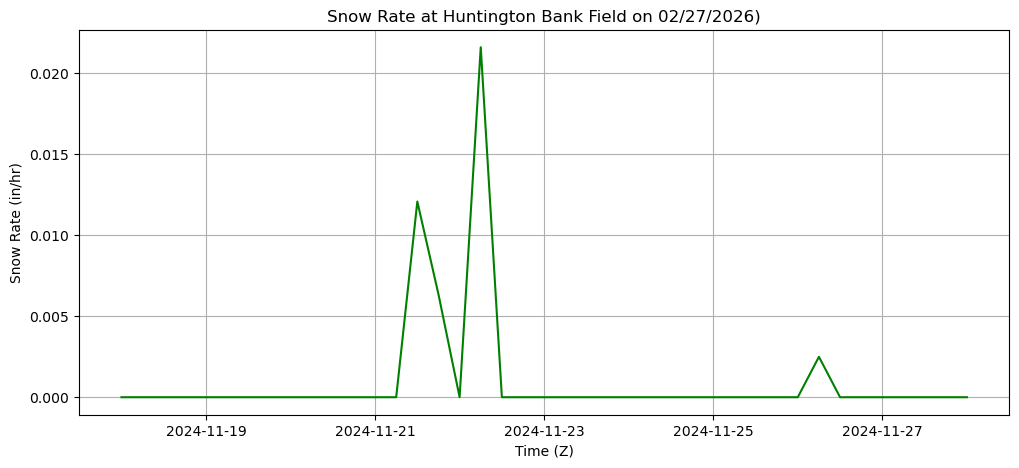

In [8]:
#PLOTS
#Extract and get the location and time 
ds = xr.open_dataset(path)
ds = ds.assign_coords(longitude=((ds.longitude + 180) % 360) - 180)
point = ds.sel(latitude=41.5061, longitude=-81.6995, method='nearest')
time = point['valid_time']

#AMBIENT TEMPERATURE PLOT
tempF = (point['t2m'] - 273.15) * 9/5 + 32
plt.figure(figsize=(12, 5))
plt.plot(time, tempF, color='green') 
plt.title('Ambient Temperature at Huntington Bank Field on 02/27/2026') 
plt.xlabel('Time (Z)')  
plt.ylabel('Ambient Temperature (°F)') 
plt.grid()
plt.show() #Show the plot


#WIND SPEED PLOT 
wind_kts = (np.sqrt(point['u10']**2 + point['v10']**2)) * 1.94384449
plt.figure(figsize=(12, 5))
plt.plot(time, wind_kts, color='green')
plt.title('Wind Speed at Huntington Bank Field on 02/27/2026')
plt.xlabel('Time (Z)')
plt.ylabel('Wind Speed (kts)')
plt.grid()
plt.show()


#WIND DIRECTION PLOT 
wind_deg = (270-np.degrees(np.arctan2(point['v10'], point['u10']))) % 360
plt.figure(figsize=(12, 5))
plt.plot(time, wind_deg, color='green')
plt.title('Wind Direction at Huntington Bank Field on 02/27/2026')
plt.xlabel('Time (Z)')
plt.ylabel('Wind Direction (°)')
plt.grid()
plt.show()


#RAIN RATE PLOT 
rain = point['prate'] * 3600 * 0.03937 
plt.figure(figsize=(12, 5))
plt.plot(time, rain, color='green')
plt.title('Rain Rate at Huntington Bank Field on 02/27/2026)')
plt.xlabel('Time (Z)')
plt.ylabel('Rain Rate (in/hr)')
plt.grid()
plt.show()
          
          
#SNOW RATE PLOT
snow = point['csnow'] * rain
plt.figure(figsize=(12, 5))
plt.plot(time, snow, color='green')
plt.title('Snow Rate at Huntington Bank Field on 02/27/2026)')
plt.xlabel('Time (Z)')
plt.ylabel('Snow Rate (in/hr)')
plt.grid()
plt.show()



In [9]:
# Create the base map
def makebasemap():
    fig = plt.figure(figsize=(24,18))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-130, -65, 24, 50])  # CONUS
    ax.add_feature(cfeature.COASTLINE, edgecolor='lightblue')
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, edgecolor='gray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

#****CODE TO PLOT THE STADIUM NAMES****

# Coordinates for every NFL Stadium
    Stadiums = {
        'State Farm\nStadium': (33.5276, -112.2626),
        'Mercedes-Benz Stadium': (33.7550, -84.4008),
        'M&T Bank Stadium': (39.2779, -76.6227),
        'HighMark Stadium': (42.7738, -78.7868),
        'Bank of America Stadium': (35.2251, -80.8529),
        'Soldier Field': (41.8623, -87.6167),
        'Paycor Stadium': (39.0954, -84.5160),
        'Huntington Bank Field': (41.5061, -81.6995),
        'AT&T Stadium': (32.7473, -97.0945),
        'Empower Field\nat Mile High': (39.7439, -105.0201),
        'Ford Field': (42.3400, -83.0456),
        'Lambeau Field': (44.5013, -88.0622),
        'NRG Stadium': (29.6847, -95.4107),
        'Lucas Oil Stadium': (39.7601, -86.1639),
        'TIAA Bank Field': (30.3239, -81.6373),
        'GEHA Field at\nArrowhead Stadium': (39.0489, -94.4849),
        'Allegiant Stadium': (36.0908, -115.1830),
        'SoFi Stadium': (33.9535, -118.3392),
        'Hard Rock Stadium': (25.9580, -80.2389),
        'U.S. Bank Stadium': (44.9738, -93.2575),
        'Gillette Stadium': (42.0909, -71.2643),
        'Caesars\nSuperdome': (29.9511, -90.0812),
        'Metlife Stadium': (40.8135, -74.0745),
        'Lincoln Financial Field': (39.9008, -75.1675),
        'Acrisure Stadium': (40.4468, -80.0158),
        "Levi's Stadium": (37.4030, -121.9700),
        'Lumen Field': (47.5952, -122.3316),
        'Raymond James Stadium': (27.9759, -82.5033),
        'Nissan Stadium': (36.1665, -86.7713),
        'Northwest Field': (38.9078, -76.8644),
    }

# Plot stadiums
    for stadium, (lat, lon) in Stadiums.items():
        ax.plot(lon, lat, marker='o', color='black', markersize=8,
                markeredgecolor='white', transform=ccrs.PlateCarree())
        ax.text(lon + 0.5, lat + 0.2, stadium, fontsize=8,
                fontweight='bold', transform=ccrs.PlateCarree())
    return fig, ax

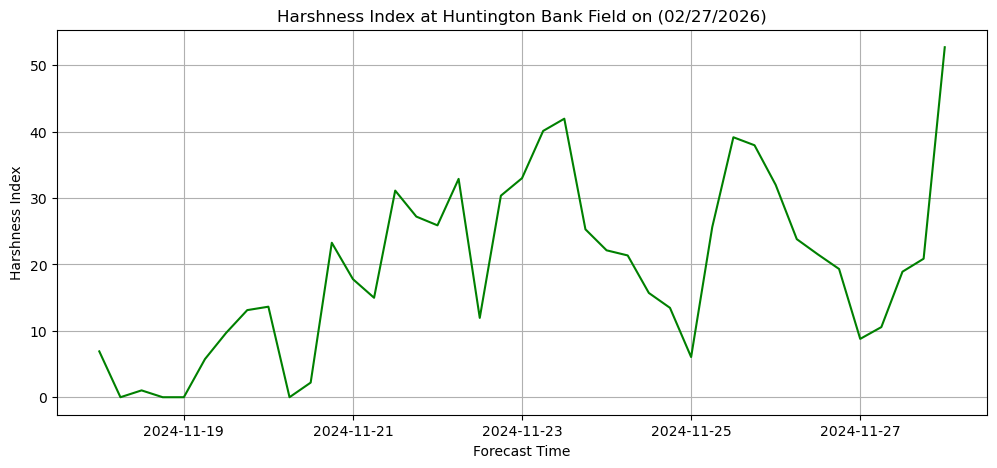

In [23]:

def points(fl, windmph, rain, snow):

# APPARENT TEMPERATURE
# I used AI to help write the temperature contributions in xarray code since that is what we used in our original index back in milestone 1
    temp_contribution = xr.zeros_like(fl)
    mask = ((fl >= 75) & (fl < 85))
    temp_contribution = xr.where(mask, (fl - 75) / 10, temp_contribution)
    mask = ((fl >= 85) & (fl < 105))
    temp_contribution = xr.where(mask, 1 + ((fl - 85) / 5), temp_contribution)
    mask = fl >= 105
    temp_contribution = xr.where(mask, 5, temp_contribution)
    mask = ((fl < 50) & (fl > 0))
    temp_contribution = xr.where(mask, (50 - fl) / 10, temp_contribution)
    mask = fl <= 0
    temp_contribution = xr.where(mask, 5, temp_contribution)

#WIND SPEED
    wind_contribution = xr.zeros_like(windmph)
    mask = ((windmph >= 5) & (windmph < 20))
    wind_contribution = xr.where(mask, (windmph / 5), wind_contribution)
    mask = ((windmph >= 20) & (windmph < 30))
    wind_contribution = xr.where(mask, 4 + ((windmph - 20) / 10), wind_contribution)
    mask = windmph >= 30
    wind_contribution = xr.where(mask, 5, wind_contribution)               

#PRECIPITATION 
    # RAIN
    rain_contribution = xr.zeros_like(rain)
    mask = ((rain > 0) & (rain <= 0.4))
    rain_contribution = xr.where(mask, ((rain / 0.4) * 8), rain_contribution)
    mask = ((rain > 0.4) & (rain < 0.5))
    rain_contribution = xr.where(mask, 8 + (((rain - 0.4) / 0.1) * 2), rain_contribution)
    mask = rain >= 0.5
    rain_contribution = xr.where(mask, 10, rain_contribution)

    # SNOW
    snow_contribution = xr.zeros_like(snow)
    mask = ((snow > 0) & (snow <= 0.1))
    snow_contribution = xr.where(mask, ((snow / 0.1) * 2), snow_contribution)
    mask = ((snow > 0.1) & (snow <= 0.6))
    snow_contribution = xr.where(mask, 2 + (((snow - 0.1) / 0.5) * 5), snow_contribution)
    mask = ((snow > 0.6) & (snow < 1))
    snow_contribution = xr.where(mask, 7 + (((snow - 0.6) / 0.4) * 3), snow_contribution)
    mask = snow >= 1
    snow_contribution = xr.where(mask, 10, snow_contribution)

    # Combines the rain and snow contributions, but limits the index to only 10
    # Had to convert from xr.maximum() to np.maximum() since xr.maximum() did not work
    # Confirmed with AI that np.maximum() worked with my code
    precip_contribution = np.maximum(rain_contribution, snow_contribution)
    
    index = (temp_contribution + wind_contribution + precip_contribution)*(5)
    return index

# AI recommended me to compute index before creating the map and after returning the array
t = 16 
fl_t = fl.isel(valid_time=t)
wind_t = windmph.isel(valid_time=t)
index = points(fl_t, wind_t, rain, snow)

#CREATE THE INDEX PLOT 

#Create the variables for the desired location at the desired time 
lat = 41.5061
lon = -81.6995
pt = ds.sel(latitude=lat, longitude=lon, method='nearest')
time = pt['valid_time']

#Conversions and calcuations 
tempF = (pt['t2m'] - 273.15) * 9/5 + 32
windmph = np.sqrt(pt['u10']**2 + pt['v10']**2) * 2.237
wc = (35.7 + 0.6215 * tempF - 35.75 * (windmph ** 0.16) + 0.4275 * tempF * (windmph ** 0.16))
wctemp = xr.where((tempF <= 50) & (windmph >= 3), wc, tempF)
rh = pt['r2']
hi = (-42.379 + 2.04901523 * tempF + 10.14333127 * rh
      - 0.22475541 * tempF * rh - 0.00683783 * tempF**2
      - 0.05481717 * rh**2 + 0.00122874 * tempF**2 * rh
      + 0.00085282 * tempF * rh**2 - 0.00000199 * tempF**2 * rh**2)
hitemp = xr.where(tempF >= 80, hi, tempF)
fl = xr.where(tempF <= 50, wctemp, xr.where(tempF >= 80, hitemp, tempF))
rain = pt['prate'] * 141.73
snow = rain * 10

#Set index 
index = points(fl, windmph, rain, snow)

#Create the plot figure 
plt.figure(figsize=(12,5))
plt.plot(time, index, color='green')
plt.title('Harshness Index at Huntington Bank Field on (02/27/2026)')
plt.xlabel("Forecast Time")
plt.ylabel("Harshness Index")
plt.grid()
plt.show()
